In [1]:
#1.House Prediction using Linear Regression model 

#importing Libraries:
import pandas as pd
import seaborn as sns

In [2]:
#Step:1 
#Loading the Dataset
house_data=pd.read_csv("HousePricePrediction.csv")
house_data

,Id,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2914,2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN


In [3]:
house_data.isnull().sum()# there are some of the null values in the dataset (in MSZoning:4, BsmtfinSF2:1,Exterior1st:1,TotalBsmtSF:1


Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64

In [4]:
#Data Pre-Processing
house_data.head()
house_data.describe
house_data.isnull().sum()# there are some of the null values in the dataset (in MSZoning:4, BsmtfinSF2:1,Exterior1st:1,TotalBsmtSF:1

#Selecting the numerical and Categorical ccolumns 
num_cols=house_data.select_dtypes(include=["int64","float64"]).columns
cat_cols=house_data.select_dtypes(include=["object"]).columns

#filling the missing numerical values(mean/median) 
for col in num_cols:
    house_data[col].fillna(house_data[col].median(),inplace=True)
#filling Missing Categorical Values (Mode) 
for col in cat_cols:
    house_data[col].fillna(house_data[col].mode()[0],inplace=True)
house_data=house_data.dropna(subset=["SalePrice"])

In [5]:
house_data.isnull().sum() #Checking if any Null Values are still there

Id              0
MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

In [6]:
#Encoding 
house_data=pd.get_dummies(house_data,columns=cat_cols,drop_first=True)

In [7]:
#Feature Selection:
#Keeping only useful columns and Drop:IDs irrelavant text columns
house_data=house_data.drop(columns=["Id"],errors="ignore")
X=house_data.drop(columns=["SalePrice"]) 
y=house_data["SalePrice"] 

In [8]:
# Feature Scaling using StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Splitting Data :X-> features and y->price  

#Separating Features and targets 
X=house_data.drop(columns=["SalePrice"]) 
y=house_data["SalePrice"] 

#Splitting into train and test 
from sklearn.model_selection import train_test_split 
X_train ,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)

In [9]:
from sklearn.linear_model import LinearRegression 

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [10]:
#Step5: Making Predictions
y_pred=model.predict(X_test)

In [11]:
#Step6:Evaluating Model 
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score 
import numpy as np 

mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse) 
r2=r2_score(y_test,y_pred)

print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2 Score:",r2)

MAE: 32042.044926488652
MSE: 2441285770.7271824
RMSE: 49409.36926056821
R2 Score: 0.3371869620414253


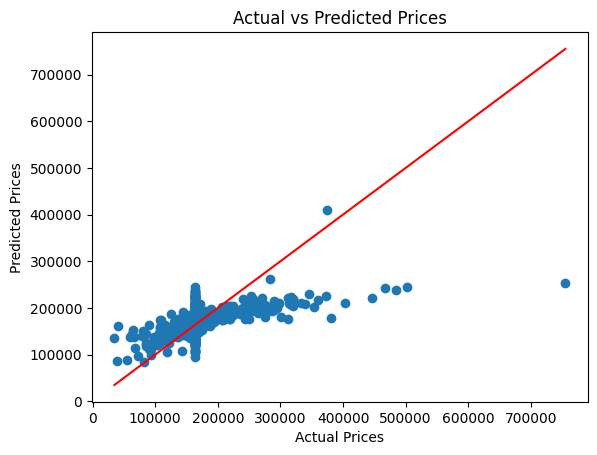

In [12]:
#Analyzing Actual vs Predicted 
import matplotlib.pyplot as plt 
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

#line for perfect prediction
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.savefig("result.png")
plt.show()